In [22]:
import os
import io
import time
import numpy as np
from PIL import Image
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode


In [23]:
def start_webcam_stream():
    js = Javascript('''
        var video;
        var stream;
        var captureCanvas;

        async function startStream() {
            const div = document.createElement('div');
            video = document.createElement('video');
            video.style.display = 'block';
            video.width = 400;
            stream = await navigator.mediaDevices.getUserMedia({video: true});
            div.appendChild(video);
            document.body.appendChild(div);
            video.srcObject = stream;
            await video.play();

            captureCanvas = document.createElement('canvas');
            captureCanvas.width = 400;
            captureCanvas.height = 300;

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
            return;
        }

        async function captureFrame() {
            const ctx = captureCanvas.getContext('2d');
            ctx.drawImage(video, 0, 0, captureCanvas.width, captureCanvas.height);
            return captureCanvas.toDataURL('image/jpeg', 0.9);
        }

        async function stopStream() {
            if (stream) {
                stream.getTracks().forEach(track => track.stop());
            }
        }
    ''')
    display(js)
    eval_js('startStream()')

def capture_frame():
    data_url = eval_js('captureFrame()')
    header, encoded = data_url.split(',', 1)
    img_bytes = b64decode(encoded)
    return Image.open(io.BytesIO(img_bytes)).convert('RGB')

def stop_webcam_stream():
    eval_js('stopStream()')

In [25]:
def collect_images(save_dir, num_images=50, interval_seconds=2, start_index=0):
    os.makedirs(save_dir, exist_ok=True)
    start_webcam_stream()
    time.sleep(2)  # let camera warm up

    out_handle = None
    saved = 0

    try:
        for i in range(num_images):
            frame = capture_frame()
            idx = start_index + i
            filepath = os.path.join(save_dir, f"{idx}.jpg")
            frame.save(filepath, "JPEG")
            saved += 1

            import matplotlib.pyplot as plt
            fig, ax = plt.subplots(figsize=(3, 2.5))
            ax.imshow(frame)
            ax.axis('off')
            ax.set_title(f"Saved {saved}/{num_images}: {filepath}")

            if out_handle is None:
                out_handle = display(fig, display_id=True)
            else:
                out_handle.update(fig)
            plt.close(fig)

            time.sleep(interval_seconds)
    except KeyboardInterrupt:
        print("Stopped early by user.")
    finally:
        stop_webcam_stream()
        print(f"\nDone. Saved {saved} images to {save_dir}")

<IPython.core.display.Javascript object>

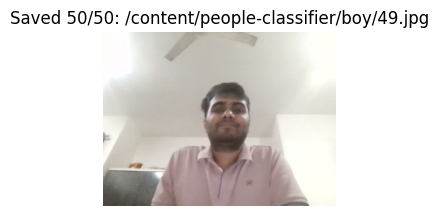


Done. Saved 50 images to /content/people-classifier/boy


In [26]:
BOY_DIR = '/content/people-classifier/boy'

collect_images(save_dir=BOY_DIR, num_images=50, interval_seconds=2)

In [27]:
import shutil

print("Images saved:", len(os.listdir(BOY_DIR)))

shutil.make_archive('/content/boy_images', 'zip', BOY_DIR)
print("Zipped to /content/boy_images.zip")

from google.colab import files
files.download('/content/boy_images.zip')

Images saved: 50
Zipped to /content/boy_images.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

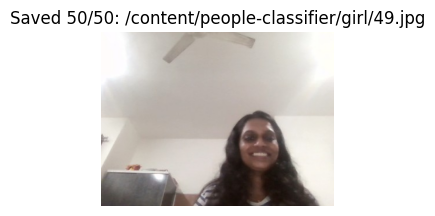


Done. Saved 50 images to /content/people-classifier/girl


In [28]:
GIRL_DIR = '/content/people-classifier/girl'

collect_images(save_dir=GIRL_DIR, num_images=50, interval_seconds=2)

In [29]:
print("Images saved:", len(os.listdir(GIRL_DIR)))

shutil.make_archive('/content/girl_images', 'zip', GIRL_DIR)
print("Zipped to /content/girl_images.zip")

files.download('/content/girl_images.zip')

Images saved: 50
Zipped to /content/girl_images.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split

In [31]:
IMG_SIZE = 100

def load_images_from_folder(folder, size=IMG_SIZE):
    images = []
    for filename in sorted(os.listdir(folder)):
        path = os.path.join(folder, filename)
        try:
            img = Image.open(path).convert('RGB')
            img = img.resize((size, size))
            img = np.array(img) / 255.0
            images.append(img)
        except Exception as e:
            print(f"Skipping {filename}: {e}")
    return np.array(images)

boy_images = load_images_from_folder(BOY_DIR)
girl_images = load_images_from_folder(GIRL_DIR)
print("Boy:", boy_images.shape, "Girl:", girl_images.shape)

Boy: (50, 100, 100, 3) Girl: (50, 100, 100, 3)


In [32]:
X = np.concatenate((boy_images, girl_images), axis=0)
y = np.concatenate((np.zeros(len(boy_images)), np.ones(len(girl_images))))

indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X, y = X[indices], y[indices]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(80, 100, 100, 3) (20, 100, 100, 3)


In [33]:
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3), padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 401ms/step - accuracy: 0.5875 - loss: 0.7759 - val_accuracy: 0.5000 - val_loss: 0.6860
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - accuracy: 0.5875 - loss: 0.6714 - val_accuracy: 0.5000 - val_loss: 0.6522
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 583ms/step - accuracy: 0.6625 - loss: 0.6228 - val_accuracy: 0.9500 - val_loss: 0.5426
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 355ms/step - accuracy: 0.8500 - loss: 0.5210 - val_accuracy: 0.9500 - val_loss: 0.3782
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 350ms/step - accuracy: 0.9375 - loss: 0.3573 - val_accuracy: 1.0000 - val_loss: 0.2351
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 345ms/step - accuracy: 0.9625 - loss: 0.2297 - val_accuracy: 1.0000 - val_loss: 0.1209
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 495ms/step - accuracy: 0.9750 - loss: 0.1369 - val_accuracy: 0.8500 - val_loss: 0.2565
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 485ms/step - accuracy: 0.9750 - loss: 0.1034 - val_accuracy: 1.0000 - val_loss:

In [34]:
model.save('/content/boy_girl_classifier.h5')
files.download('/content/boy_girl_classifier.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
LABELS = {0: "Boy", 1: "Girl"}

def classify_frame(img):
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img_resized) / 255.0
    arr = arr.reshape(1, IMG_SIZE, IMG_SIZE, 3)
    prob = model.predict(arr, verbose=0)[0][0]
    label = LABELS[1] if prob > 0.5 else LABELS[0]
    confidence = prob if prob > 0.5 else 1 - prob
    return label, confidence

In [36]:
def run_live_classification(num_snapshots=12, interval_seconds=5):
    start_webcam_stream()
    time.sleep(2)

    out_handle = None

    try:
        for i in range(num_snapshots):
            frame = capture_frame()
            label, confidence = classify_frame(frame)

            fig, ax = plt.subplots(figsize=(4, 3))
            ax.imshow(frame)
            ax.axis('off')
            ax.set_title(f"{label} ({confidence*100:.1f}% confidence)")

            if out_handle is None:
                out_handle = display(fig, display_id=True)
            else:
                out_handle.update(fig)
            plt.close(fig)

            print(f"[{i+1}/{num_snapshots}] {label} — {confidence*100:.1f}%")
            time.sleep(interval_seconds)
    except KeyboardInterrupt:
        print("Stopped by user.")
    finally:
        stop_webcam_stream()
        print("Webcam stopped.")

<IPython.core.display.Javascript object>

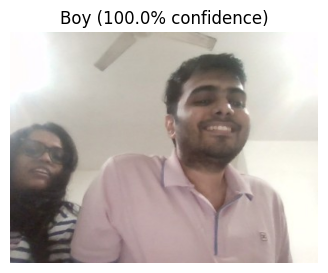

[1/12] Girl — 100.0%
[2/12] Girl — 67.0%
[3/12] Girl — 100.0%
[4/12] Girl — 100.0%
[5/12] Boy — 84.3%
[6/12] Boy — 100.0%
[7/12] Girl — 100.0%
[8/12] Boy — 100.0%
[9/12] Girl — 94.6%
[10/12] Boy — 100.0%
[11/12] Girl — 100.0%
[12/12] Boy — 100.0%
Webcam stopped.


In [37]:
import matplotlib.pyplot as plt

run_live_classification(num_snapshots=12, interval_seconds=5)